# Quantum Full Adder Using CNOT and Toffoli Gates

## 1. Objective
The objective of this experiment is to implement a reversible quantum full-adder circuit for binary addition and demonstrate how fundamental quantum logic gates—specifically **CNOT** and **Toffoli (CCX)** gates—can be combined to compute the binary **Sum** and **Carry-Out (Cout)** outputs.

---

## 2. Theory

### Binary Full Adder Functionality
A classical binary full adder takes three single-bit inputs:
- Two operand bits: $A$ and $B$
- One carry-in bit: $C_{in}$

It produces two binary outputs:
- **Sum**: Represents the least significant bit of the addition.
- **Carry-Out ($C_{out}$)**: Represents whether the addition generates a carry to the next higher-order bit.

The arithmetic sum equals the integer sum:
$$2 \cdot C_{out} + \text{Sum} = A + B + C_{in}$$

### Mathematical Logic
The output logic functions are defined as:
1. **Sum (Parity / Modulo-2 Addition)**:
   $$\text{Sum} = A \oplus B \oplus C_{in}$$
   The Sum bit evaluates to $1$ when an odd number of inputs are $1$, and $0$ when an even number of inputs are $1$.

2. **Carry-Out (Majority Function)**:
   $$C_{out} = (A \cdot B) \oplus (A \cdot C_{in}) \oplus (B \cdot C_{in})$$
   Because at most one of the pairwise products $(A \cdot B)$, $(A \cdot C_{in})$, or $(B \cdot C_{in})$ can be active unless all three inputs are $1$ (in which case $1 \oplus 1 \oplus 1 = 1$), the modulo-2 sum over GF(2) exactly matches the classical boolean majority function $(A \cdot B) \lor (A \cdot C_{in}) \lor (B \cdot C_{in})$.

### Reversible Quantum Logic Gates
Conventional classical gates (such as AND, OR, and NAND) are irreversible and lose information (erasure of bits dissipates heat according to Landauer's principle). Quantum mechanics requires all operations to be unitary and reversible:
- **CNOT (Controlled-NOT) Gate**:
  Performs an XOR operation on a target qubit conditioned on a control qubit:
  $$|c\rangle |t\rangle \xrightarrow{\quad CX \quad} |c\rangle |t \oplus c\rangle$$
  When the target qubit is initialized in state $|0\rangle$, cascading CNOT gates computes the parity of multiple control bits.
- **Toffoli (CCX / Controlled-Controlled-NOT) Gate**:
  Applies a bit-flip to the target qubit if and only if both control qubits are in state $|1\rangle$:
  $$|c_1, c_2\rangle |t\rangle \xrightarrow{\quad CCX \quad} |c_1, c_2\rangle |t \oplus (c_1 \cdot c_2)\rangle$$
  When the target qubit starts in $|0\rangle$, the Toffoli gate reversibly computes the logical product (AND) of two control qubits:
  $$|c_1, c_2\rangle |0\rangle \to |c_1, c_2\rangle |c_1 \cdot c_2\rangle$$

## 3. Circuit Architecture & Qubit Allocation
The quantum full adder is constructed using 5 quantum qubits and 5 classical bits:

- **Input Qubits**:
  - `q_0` ($A$): First input bit, set to $|1\rangle$ using a Pauli-X gate if $A = 1$.
  - `q_1` ($B$): Second input bit, set to $|1\rangle$ using a Pauli-X gate if $B = 1$.
  - `q_2` ($C_{in}$): Carry-in bit, set to $|1\rangle$ using a Pauli-X gate if $C_{in} = 1$.
- **Sum Qubit (`q_3`)**:
  - Initialized to $|0\rangle$.
  - Computes $\text{Sum} = A \oplus B \oplus C_{in}$ using three sequential CNOT gates:
    - `qc.cx(0, 3)` computes $|A\rangle$
    - `qc.cx(1, 3)` computes $|A \oplus B\rangle$
    - `qc.cx(2, 3)` computes $|A \oplus B \oplus C_{in}\rangle$
- **Carry-Out Qubit (`q_4`)**:
  - Initialized to $|0\rangle$.
  - Computes $C_{out} = (A \cdot B) \oplus (A \cdot C_{in}) \oplus (B \cdot C_{in})$ using three Toffoli gates:
    - `qc.ccx(0, 1, 4)` adds $A \cdot B$
    - `qc.ccx(0, 2, 4)` adds $A \cdot C_{in}$
    - `qc.ccx(1, 2, 4)` adds $B \cdot C_{in}$
- **Measurement Register**:
  - All 5 qubits are measured into their corresponding classical bits ($q_i \to c_i$).
  - In Qiskit's classical bitstring convention ($c_4 c_3 c_2 c_1 c_0$):
    - `output[0]` corresponds to $c_4$ ($C_{out}$).
    - `output[1]` corresponds to $c_3$ ($\text{Sum}$).

---

## 4. Input Combinations & Simulation Setup
- The implementation systematically evaluates all $2^3 = 8$ binary input combinations:
  $$(A, B, C_{in}) \in \{0, 1\}^3$$
- For each combination, the circuit is initialized, simulated on Qiskit Aer's `AerSimulator()` with `shots=1` (since the circuit is deterministic in the computational basis), and the resulting $\text{Sum}$ and $C_{out}$ values are verified against the expected classical truth table.
- The results are plotted using Matplotlib to show the progression of Sum and Carry outputs across all 8 input cases.

/var/folders/yp/078pyxw11mq6g7sd_2ty18z80000gn/T/ipykernel_2596/1470368904.py:1: DeprecationWarning: Using Qiskit with Python 3.9 is deprecated as of the 2.1.0 release. Support for running Qiskit with Python 3.9 will be removed in the 2.3.0 release, which coincides with when Python 3.9 goes end of life.
  from qiskit import QuantumCircuit


FULL ADDER RESULTS
A=0, B=0, Cin=0 -> Sum=0, Cout=0
A=0, B=0, Cin=1 -> Sum=1, Cout=0
A=0, B=1, Cin=0 -> Sum=1, Cout=0
A=0, B=1, Cin=1 -> Sum=0, Cout=1
A=1, B=0, Cin=0 -> Sum=1, Cout=0
A=1, B=0, Cin=1 -> Sum=0, Cout=1
A=1, B=1, Cin=0 -> Sum=0, Cout=1
A=1, B=1, Cin=1 -> Sum=1, Cout=1


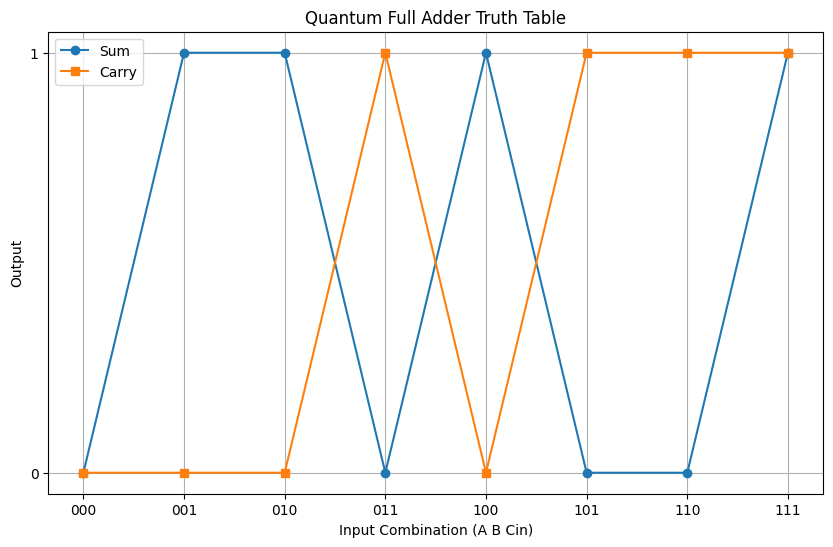

In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

def full_adder(A, B, Cin):

    qc = QuantumCircuit(5, 5)

    if A:
        qc.x(0)

    if B:
        qc.x(1)

    if Cin:
        qc.x(2)

    qc.cx(0, 3)
    qc.cx(1, 3)
    qc.cx(2, 3)

    qc.ccx(0, 1, 4)
    qc.ccx(0, 2, 4)
    qc.ccx(1, 2, 4)

    qc.measure(0, 0)
    qc.measure(1, 1)
    qc.measure(2, 2)
    qc.measure(3, 3)
    qc.measure(4, 4)

    return qc


simulator = AerSimulator()

inputs = []
sums = []
carries = []

print("FULL ADDER RESULTS")
print("=" * 50)

for A in [0, 1]:
    for B in [0, 1]:
        for Cin in [0, 1]:

            qc = full_adder(A, B, Cin)

            result = simulator.run(
                qc,
                shots=1
            ).result()

            counts = result.get_counts()
            output = list(counts.keys())[0]

            cout = int(output[0])
            sum_bit = int(output[1])

            inputs.append(f"{A}{B}{Cin}")
            sums.append(sum_bit)
            carries.append(cout)

            print(
                f"A={A}, B={B}, Cin={Cin} "
                f"-> Sum={sum_bit}, Cout={cout}"
            )

x = range(len(inputs))

plt.figure(figsize=(10, 6))

plt.plot(
    x,
    sums,
    marker='o',
    label='Sum'
)

plt.plot(
    x,
    carries,
    marker='s',
    label='Carry'
)

plt.xticks(
    list(x),
    inputs
)

plt.xlabel("Input Combination (A B Cin)")
plt.ylabel("Output")
plt.title("Quantum Full Adder Truth Table")
plt.yticks([0, 1])
plt.grid(True)
plt.legend()

plt.show()

## 5. Results & Observations

### Observed Output Stream
Executing the circuit over all 8 binary input configurations yields the following results:

```
FULL ADDER RESULTS
==================================================
A=0, B=0, Cin=0 -> Sum=0, Cout=0
A=0, B=0, Cin=1 -> Sum=1, Cout=0
A=0, B=1, Cin=0 -> Sum=1, Cout=0
A=0, B=1, Cin=1 -> Sum=0, Cout=1
A=1, B=0, Cin=0 -> Sum=1, Cout=0
A=1, B=0, Cin=1 -> Sum=0, Cout=1
A=1, B=1, Cin=0 -> Sum=0, Cout=1
A=1, B=1, Cin=1 -> Sum=1, Cout=1
```

### Full-Adder Truth Table Verification
The observed outputs match the theoretical full-adder specification across all input cases:

| Case | $A$ | $B$ | $C_{in}$ | Integer Sum ($A + B + C_{in}$) | Observed $\text{Sum}$ | Observed $C_{out}$ | Binary Output ($C_{out}\text{Sum}_2$) |
|:----:|:---:|:---:|:--------:|:------------------------------:|:--------------------:|:------------------:|:-------------------------------------:|
| 1    | 0   | 0   | 0        | 0                              | **0**                | **0**              | $00_2$                                |
| 2    | 0   | 0   | 1        | 1                              | **1**                | **0**              | $01_2$                                |
| 3    | 0   | 1   | 0        | 1                              | **1**                | **0**              | $01_2$                                |
| 4    | 0   | 1   | 1        | 2                              | **0**                | **1**              | $10_2$                                |
| 5    | 1   | 0   | 0        | 1                              | **1**                | **0**              | $01_2$                                |
| 6    | 1   | 0   | 1        | 2                              | **0**                | **1**              | $10_2$                                |
| 7    | 1   | 1   | 0        | 2                              | **0**                | **1**              | $10_2$                                |
| 8    | 1   | 1   | 1        | 3                              | **1**                | **1**              | $11_2$                                |

### Visual Pattern Analysis
The generated plot clearly illustrates the two distinct logic functions:
- **Sum Curve**: Toggles between $0$ and $1$ depending on parity, yielding $1$ whenever exactly one or three inputs are active.
- **Carry-Out Curve**: Remains $0$ for inputs with weight $\le 1$ and switches to $1$ whenever two or more inputs are active (cases `011`, `101`, `110`, and `111`).

## 6. Conclusion
This experiment successfully demonstrates the construction and verification of a **reversible Quantum Full Adder** using CNOT and Toffoli gates.

Key takeaways:
1. **Reversible Arithmetic**: By utilizing ancilla target qubits ($q_3$ and $q_4$), the circuit computes binary addition without destroying input data or violating quantum reversibility.
2. **Parity via CNOT**: Three cascaded CNOT gates implement the 3-input XOR operation to determine the binary Sum.
3. **Carry via Toffoli**: Three Toffoli gates reversibly compute the majority carry condition $(A \cdot B) \oplus (A \cdot C_{in}) \oplus (B \cdot C_{in})$.
4. **Complete Truth Table Fidelity**: Testing all 8 input combinations on Qiskit Aer confirmed $100\%$ agreement with the classical binary adder truth table.